# Churn Prediction
Shortcut to run all blocks: ESC, CTRL + A, SHIFT + ENTER

## Imports

In [1736]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, Normalizer

# For working with imbalanced datasets
from sklearn.utils import resample
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, ADASYN

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Extra Classifiers
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
import xgboost as xgb

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, f1_score

## Dataset Info

In [1738]:
CSV_FILE = "Churn_Modelling.csv"
TARGET = "Exited"
UNNECESSARY_FEATURES = ["RowNumber", "CustomerId", "Surname"]
NOMINAL_FEATURES = ["Surname", "Geography", "Gender"]
SELECTED_NOMINAL_FEATURES = list(set(NOMINAL_FEATURES) - set(UNNECESSARY_FEATURES))
FEATURED_DISTRIBUTIONS = ["CreditScore", "Geography", "Gender", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary"]
RANDOM_STATE = 123
THRESHOLD_FOR_FEATURE_REMOVAL = 0.8
ROWS_TO_DISPLAY = 3

data_frame = pd.read_csv(CSV_FILE)
data_frame

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Dataset Statistics

In [1655]:
data_frame.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## No Values Missing

In [1656]:
data_frame.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Display Target Class Imbalance

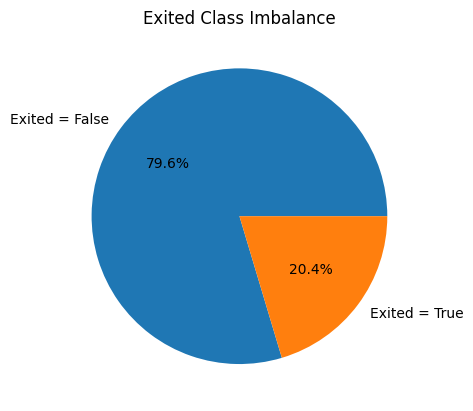

In [1657]:
# https://wellsr.com/python/upsampling-and-downsampling-imbalanced-data-in-python/
def frame_target_imbalance(df):
    df.groupby(TARGET).size().plot(kind="pie", y=TARGET, title=f"{TARGET} Class Imbalance", labels=[f"{TARGET} = False", f"{TARGET} = True"], autopct="%1.1f%%")

frame_target_imbalance(data_frame)

## Temporarily Label Encode Selected Nominal Features
This is temporarily done so these features will be shown on the box plot. Using the dataset with Nominal Features being Label Encoded is bad practice because a model might think there is some order to the Nominal Features when there isn't one in reality. We will transform the data frame to use One-hot encoding before training and testing later on. For more information, see https://stackoverflow.com/questions/36631163/what-are-the-pros-and-cons-between-get-dummies-pandas-and-onehotencoder-sciki. Finally, note that One-hot encoding led to an improvement in the Decision Tree's performance below.

In [1658]:
label_encoder = LabelEncoder()
for nominal_feature in SELECTED_NOMINAL_FEATURES:
    current_feature_values = data_frame[nominal_feature]
    label_encoder.fit(current_feature_values)
    data_frame[nominal_feature] = label_encoder.transform(current_feature_values)
data_frame.head(ROWS_TO_DISPLAY)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1


## Show Feature Distributions

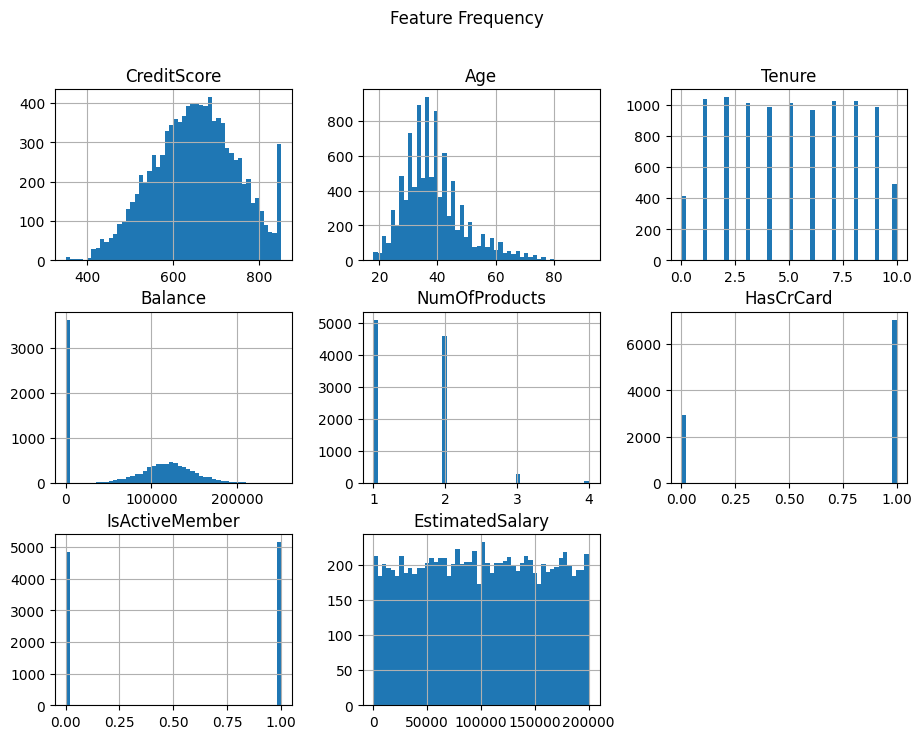

In [1758]:
data_frame[FEATURED_DISTRIBUTIONS].hist(figsize=(11, 8), bins=50)
plt.suptitle("Feature Frequency")
plt.show()

## Feature Removal

In [1659]:
data_frame = data_frame.drop(columns=UNNECESSARY_FEATURES)
data_frame.head(ROWS_TO_DISPLAY)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1


## Show Unscaled Features

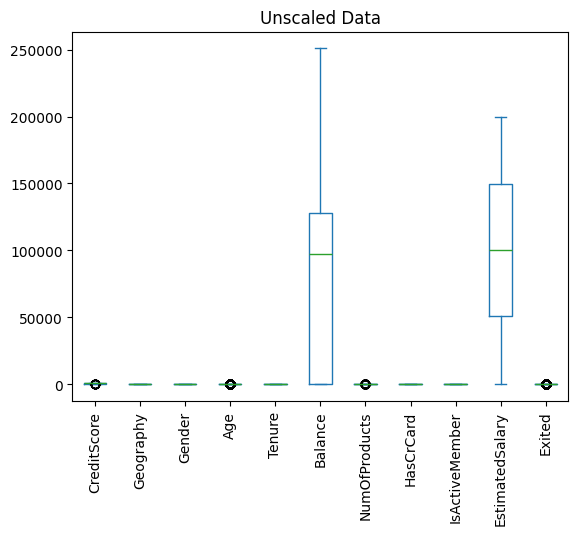

In [1660]:
def frame_box_plot(df, title):
    df.plot(kind="box")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

frame_box_plot(data_frame, "Unscaled Data")

## Show Scaled Features

**NOTE**: Do not use "data_frame_scaled" to produce training and test sets. This is because we do not want to scale the Target "Exited". We want to keep the Target as 0s and 1s. Scaling the Target will lead to problems later on, as it will instead label the values as -1 and 1 respectively. The box plot below is purely for showing the scaled features only.

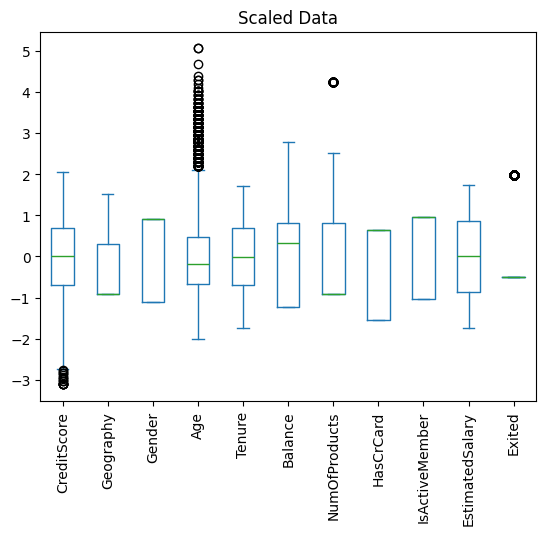

In [1661]:
def get_scaled_frame(df):
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    return pd.DataFrame(data=df_scaled, columns=df.columns)

data_frame_scaled = get_scaled_frame(data_frame)
frame_box_plot(data_frame_scaled, "Scaled Data")

## Show Normalized Features

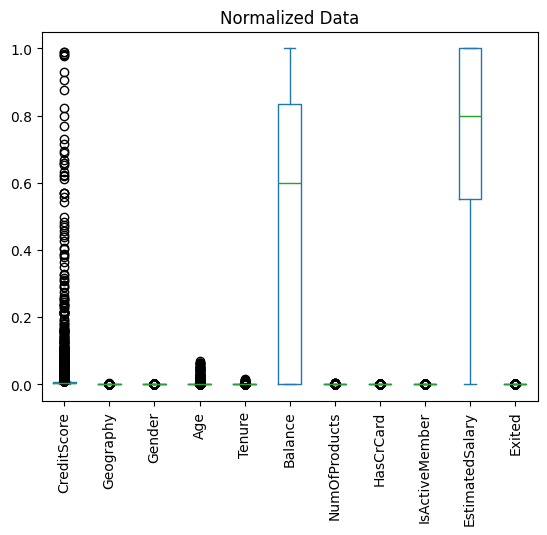

In [1662]:
def get_normalized_frame(df):
    normalizer = Normalizer()
    df_normalized = normalizer.fit_transform(df)
    return pd.DataFrame(data=df_normalized, columns=df.columns)

data_frame_normalized = get_normalized_frame(data_frame)
frame_box_plot(data_frame_normalized, "Normalized Data")

## Choosing Outliers for Removal in Training
NumOfProducts seems like it might cause some generalization issues for our models.
Age seems like it captures something important. See how it relates to "Exited" in the Correlation Matrix.
**TODO**: Maybe try removing the lower end of "CreditScore" later on.

In [1663]:
# SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = []
# SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = ["Age", "NumOfProducts", "CreditScore"]
# SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = ["Age", "NumOfProducts"]
# SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = ["NumOfProducts", "CreditScore"]
SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = ["NumOfProducts"]

## One-hot Encoding
**TODO**: Should we set drop_first=True for certain models? See https://datascience.stackexchange.com/questions/47638/in-which-cases-shouldnt-we-drop-the-first-level-of-categorical-variables for more information.

In [1664]:
data_frame = pd.get_dummies(data_frame, columns=SELECTED_NOMINAL_FEATURES, drop_first=False)
data_frame.head(ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_0,Geography_1,Geography_2,Gender_0,Gender_1
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False


## Show Correlation Among Features

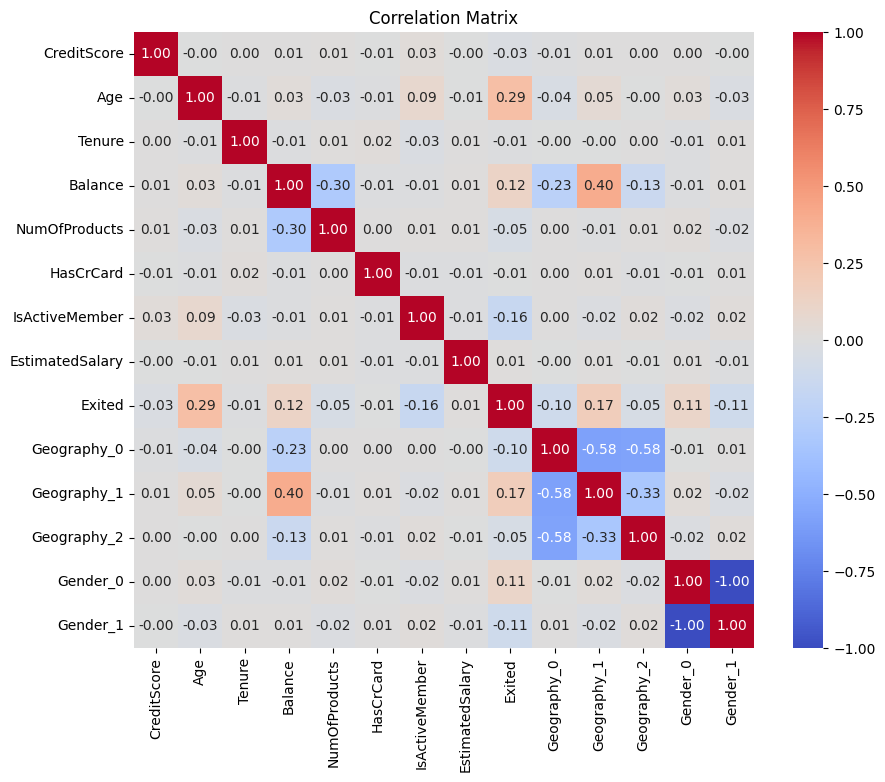

In [1665]:
def frame_correlation_matrix(df, threshold=0):
    correlation_matrix = df.corr()
    correlation_matrix[abs(correlation_matrix) < threshold] = 0
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

frame_correlation_matrix(data_frame)

## Show Features with Highest Correlation

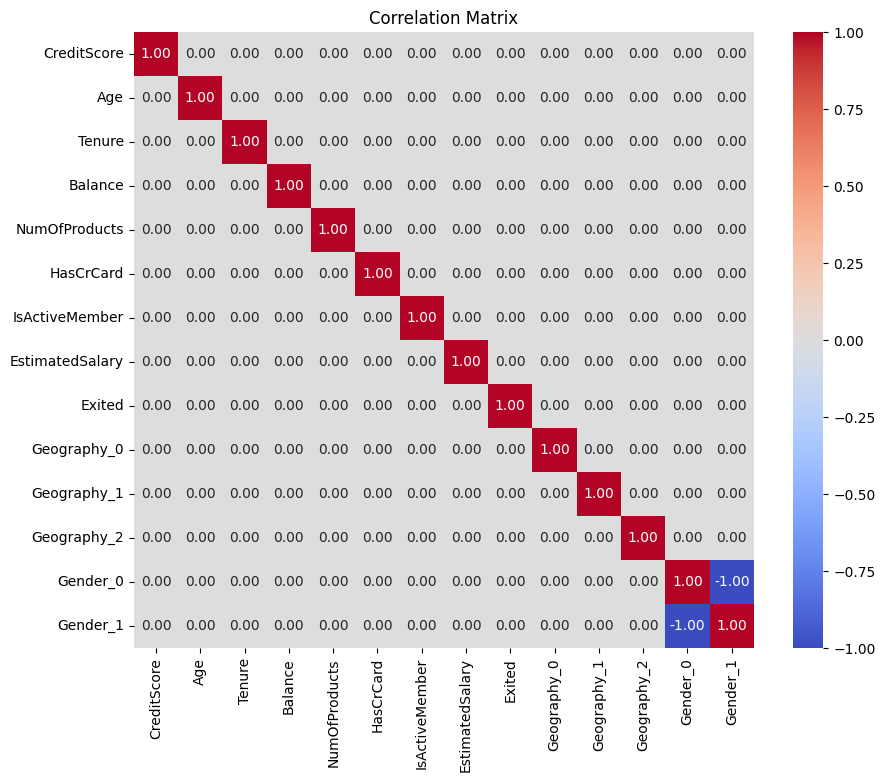

In [1666]:
frame_correlation_matrix(data_frame, THRESHOLD_FOR_FEATURE_REMOVAL)

## Drop One Gender Column to Reduce Dimensionality
We do this because it is highly correlated with the other Gender column.

In [1667]:
data_frame = data_frame.drop(columns=["Gender_1"])
data_frame.head(ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_0,Geography_1,Geography_2,Gender_0
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True


## Define Unscaled Features and Target

In [1668]:
def get_x_y(df, scale=False, normalize=False):
    x = df.drop(columns=[TARGET])
    if scale:
        x = get_scaled_frame(x)
    elif normalize:
        x = get_normalized_frame(x)
    y = df[TARGET]
    return x, y

x, y = get_x_y(data_frame)
x.head(ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True


## Define Scaled Features
**TODO**: Add normalization. Look into which models benefit from unscaled, scaled and normalized data.

In [1669]:
x_scaled, _ = get_x_y(data_frame, scale=True)
x_normalized, _ = get_x_y(data_frame, scale=False, normalize=True)
x_scaled.head(ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_0,Geography_1,Geography_2,Gender_0
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,0.997204,-0.578736,-0.573809,1.095988
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-1.002804,-0.578736,1.742740,1.095988
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,0.997204,-0.578736,-0.573809,1.095988


## Skipping Principal Component Analysis
Based on a little bit of research, it seems safer to omit PCA from our project.

## Define Functions for Testing Models

In [1670]:
def call_train_test_split(x, y):
    return train_test_split(x, y, test_size=0.2, train_size=0.8, random_state=RANDOM_STATE, stratify=y)

def custom_train_test_split(x, y, selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False):
    x_train, x_test, y_train, y_test = call_train_test_split(x, y)
    
    # https://stackoverflow.com/questions/74683825/how-do-i-remove-outliers-from-a-column-in-a-dataframe
    # Reconstruct data frame using x and y. Essentially, concatenate x with y to produce the original dataframe.
    # This is done because we need to keep x and y consistent with each other.
    df_train = x.copy()
    df_train[TARGET] = y
    if selected_outliers:
        # When we remove an outlier from x, we also need to remove the corresponding row in y.
        for outlier in selected_outliers:
            quantile1 = df_train[outlier].quantile(0.25)
            quantile3 = df_train[outlier].quantile(0.75)
            interquartile_range = quantile3 - quantile1

            low = quantile1 - 1.5 * interquartile_range
            high = quantile3 + 1.5 * interquartile_range

            df_train = df_train[df_train[outlier] > low]
            df_train = df_train[df_train[outlier] < high]

        x_removed_outliers, y_removed_outliers = get_x_y(df_train)
        x_train, _, y_train, _ = call_train_test_split(x_removed_outliers, y_removed_outliers)

    if upsample_minority:
        df_train_minority = df_train[df_train[TARGET] == 1]
        df_train_majority = df_train[df_train[TARGET] == 0]

        df_train_minority_upsample = resample(df_train_minority, replace=True, n_samples=len(df_train_majority), random_state=RANDOM_STATE)
        df_train_upsample = pd.concat([df_train_majority, df_train_minority_upsample])

        x_minority_upsample, y_minority_upsample = get_x_y(df_train_upsample)
        x_train, _, y_train, _ = call_train_test_split(x_minority_upsample, y_minority_upsample)

    if add_synthetic_training_data:
        adasyn = ADASYN(random_state=RANDOM_STATE)
        smote = SMOTE(random_state=RANDOM_STATE)
        smote_enn = SMOTEENN(random_state=RANDOM_STATE)
        
        x_train, y_train = adasyn.fit_resample(x_train, y_train)
        # x_train, y_train = smote.fit_resample(x_train, y_train)
        # x_train, y_train = smote_enn.fit_resample(x_train, y_train)
    
    return x_train, x_test, y_train, y_test

def test_model(model, x, y, selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False, output=True):
    x_train, x_test, y_train, y_test = custom_train_test_split(x, y, selected_outliers, upsample_minority, add_synthetic_training_data)
    model.fit(x_train, y_train)
    y_train_predicted = model.predict(x_train)
    y_test_predicted = model.predict(x_test)

    if output:
        print(model)
        print(f"{selected_outliers=}, {upsample_minority=}, {add_synthetic_training_data=}")
        print("\nTraining Report:")
        print(classification_report(y_train, y_train_predicted))
        print("\nTest Report and Results:")
        print(classification_report(y_test, y_test_predicted))
    
        confusion_matrix_test = confusion_matrix(y_test, y_test_predicted)
        confusion_matrix_display = ConfusionMatrixDisplay(confusion_matrix_test, display_labels=model.classes_)
        figure, axes = plt.subplots(figsize=(2, 2))
        confusion_matrix_display.plot(ax=axes)
        plt.show()
    
        predict_proba = getattr(model, "predict_proba", None)
        if callable(predict_proba):
            y_test_predicted_class_probabilities = model.predict_proba(x_test)
            y_test_predicted_minority_probabilites = y_test_predicted_class_probabilities[:, 1]
            false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_test_predicted_minority_probabilites)
            area_under_curve = auc(false_positive_rate, true_positive_rate)
            plt.figure(figsize=(4, 2.5))
            # PLot straight dotted diagonal line from (0, 0) to (1, 1)
            plt.plot([0, 1], [0, 1], linestyle="--")
            # Plot true positive rate against false positive rate with a label for area under the ROC curve
            plt.plot(false_positive_rate, true_positive_rate, label=f"ROC curve (area = {area_under_curve:.2f})")
            plt.title(f"ROC Curve")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend()
            plt.show()
        
        if type(model) == type(DecisionTreeClassifier()):
            plot_tree(model, filled=True)

    training_f1_score = f1_score(y_train, y_train_predicted)
    test_f1_score = f1_score(y_test, y_test_predicted)
    return training_f1_score, test_f1_score
    # return model

## Imbalanced Dataset Handling

In [1671]:
def generate_binary_class_weights(rate_of_change=0.05, majority_class=0, minority_class=1):
    class_weights = []
    assert rate_of_change > 0
    majority_value = 1 - rate_of_change
    minority_value = 1 - majority_value
    while majority_value > 0 and minority_value < 1:
        class_weight = {}
        class_weight[majority_class] = round(majority_value, 2)
        class_weight[minority_class] = round(1 - majority_value, 2)

        majority_value -= rate_of_change

        class_weights.append(class_weight)

    return class_weights

CLASS_WEIGHTS = generate_binary_class_weights()

## Hyperparameter Tuning

In [1672]:
def tune_hyperparameters(model, x, y, parameter_grid, selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False):
    scoring = "f1"
    error_score = "raise"
    
    grid_search = GridSearchCV(model, param_grid=parameter_grid, scoring=scoring, error_score=error_score)

    x_train, _, y_train, _ = custom_train_test_split(x, y, selected_outliers, upsample_minority, add_synthetic_training_data)
    grid_search.fit(x_train, y_train)
    tuned_model = grid_search.best_estimator_
    print(f"{tuned_model=}")
    return tuned_model

## Decision Tree

DecisionTreeClassifier(random_state=123)
selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      1630

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1593
           1       0.49      0.50      0.49       407

    accuracy                           0.79      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.79      0.79      0.79      2000



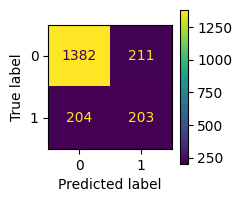

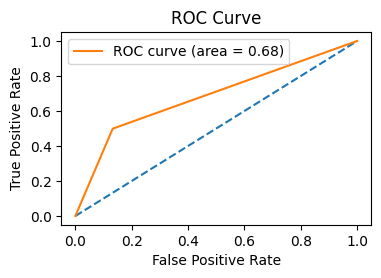

(1.0, 0.4945188794153471)

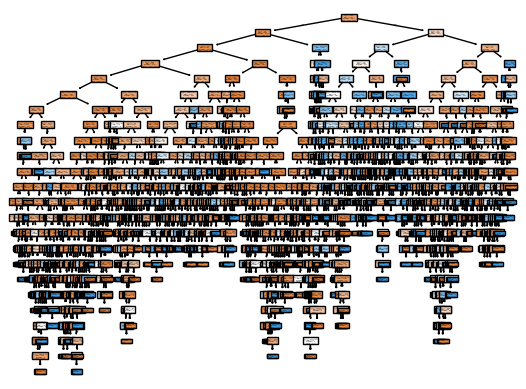

In [1673]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
test_model(tree, x, y)

## Tune Decision Tree
**NOTE**: Probably shouldn't use normalized x for Decision Tree, but it works, we should probably change it back to x_scaled or x by itself.

tuned_model=DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, random_state=123)
DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, random_state=123)
selected_outliers=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5607
           1       1.00      1.00      1.00      5607

    accuracy                           1.00     11214
   macro avg       1.00      1.00      1.00     11214
weighted avg       1.00      1.00      1.00     11214


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1593
           1       0.89      0.89      0.89       407

    accuracy                           0.95      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.95      0.95      0.95      2000



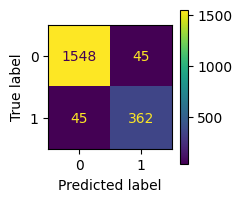

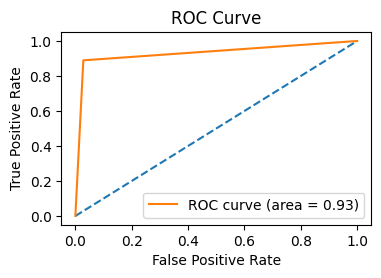

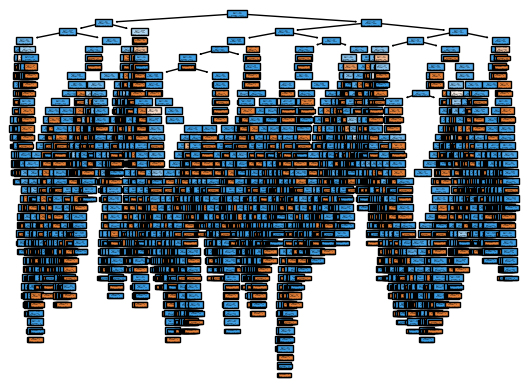

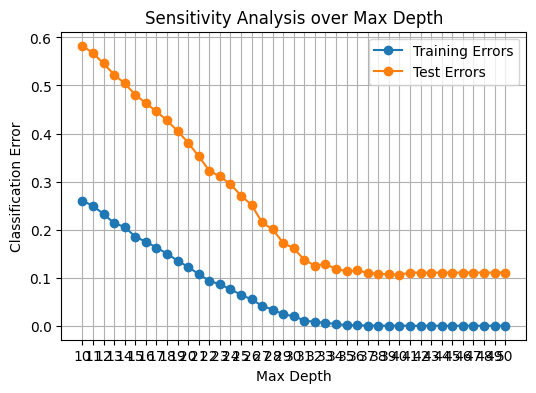

In [1674]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_parameter_grid = {"class_weight": CLASS_WEIGHTS}
tuned_tree = tune_hyperparameters(tree, x_normalized, y, tree_parameter_grid, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, upsample_minority=True, add_synthetic_training_data=False)
test_model(tuned_tree, x_normalized, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, upsample_minority=True)

training_errors = []
test_errors = []
max_depth_values = range(10, 51)
for max_depth in max_depth_values:
    tuned_tree.max_depth = max_depth
    training_score, test_score = test_model(tuned_tree, x_normalized, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, upsample_minority=True, add_synthetic_training_data=False, output=False)
    training_errors.append(1 - training_score)
    test_errors.append(1 - test_score)

plt.figure(figsize=(6, 4))
#You code starts here
plt.plot(max_depth_values, training_errors, marker="o", label="Training Errors")
plt.plot(max_depth_values, test_errors, marker="o", label="Test Errors")
#Your code ends here
plt.title("Sensitivity Analysis over Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Classification Error")
plt.xticks(max_depth_values)
plt.grid(True)
plt.legend()
plt.show()

In [1675]:
tree_parameter_grid = {"max_depth": range(10,51)}
tuned_tree = tune_hyperparameters(tuned_tree, x_normalized, y, tree_parameter_grid, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, upsample_minority=True)

tuned_model=DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, max_depth=45,
                       random_state=123)


## Cost Complexity Pruning

In [1696]:
x_train, _, y_train, _ = custom_train_test_split(x_normalized, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, upsample_minority=True)
cost_complexity_pruning_path = tuned_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = cost_complexity_pruning_path.ccp_alphas

test_scores = []
best_f1_pruned = 0
best_ccp_alpha = 0

tuned_tree = DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, max_depth=45,random_state=RANDOM_STATE)

for ccp_alpha in ccp_alphas:
    tuned_tree.ccp_alpha = ccp_alpha
    _, test_f1_pruned = test_model(tuned_tree, x_normalized, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, upsample_minority=True, add_synthetic_training_data=False, output=False)
    test_scores.append(test_f1_pruned)

    print(f"Accuracy for {ccp_alpha=}: {test_f1_pruned}")
    
    if test_f1_pruned > best_f1_pruned:
        best_f1_pruned = test_f1_pruned
        best_ccp_alpha = ccp_alpha

print(f"F1 for {best_ccp_alpha=}: {best_f1_pruned}")

Accuracy for ccp_alpha=np.float64(0.0): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(1.7820594295748886e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(1.7820594295748886e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(2.772092446005383e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(2.772092446005383e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(2.772092446005383e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(2.772092446005383e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(2.772092446005383e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(2.772092446005383e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(2.772092446005383e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(2.772092446005383e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(3.267108954220629e-20): 0.8894348894348895
Accuracy for ccp_alpha=np.float64(3.564118859149777e-20): 0.8894348894348895
Accuracy for cc

## Run Tuned Decision Tree

DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, max_depth=45,
                       random_state=123)
selected_outliers=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5607
           1       1.00      1.00      1.00      5607

    accuracy                           1.00     11214
   macro avg       1.00      1.00      1.00     11214
weighted avg       1.00      1.00      1.00     11214


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1593
           1       0.89      0.89      0.89       407

    accuracy                           0.95      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.95      0.95      0.95      2000



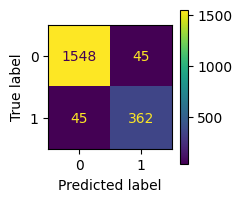

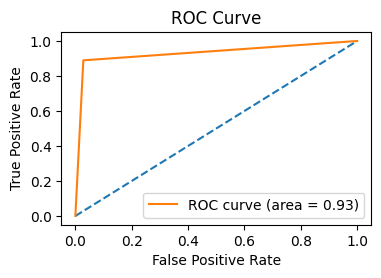

(1.0, 0.8894348894348895)

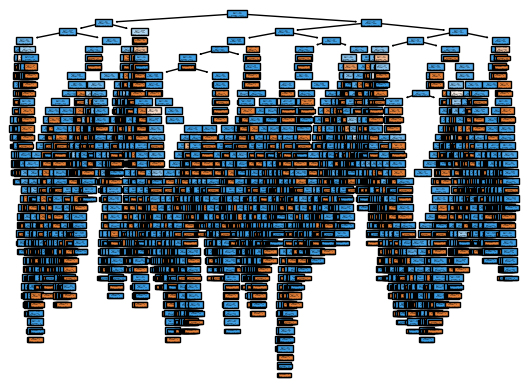

In [1677]:
tuned_tree = DecisionTreeClassifier(class_weight={0: 0.05, 1: 0.95}, max_depth=45,random_state=RANDOM_STATE)
test_model(tuned_tree, x_normalized, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, upsample_minority=True)

## Support Vector Machine

SVC(random_state=123)
selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      6370
           1       0.00      0.00      0.00      1630

    accuracy                           0.80      8000
   macro avg       0.40      0.50      0.44      8000
weighted avg       0.63      0.80      0.71      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

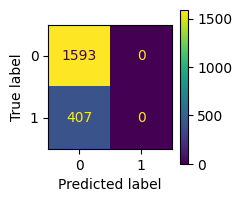

(0.0, 0.0)

In [1678]:
svm = SVC(random_state=RANDOM_STATE)
test_model(svm, x, y)

## Tune Support Vector Machine

In [1679]:
svm = SVC(random_state=RANDOM_STATE)
svm_parameter_grid = {"kernel": ["poly", "rbf", "sigmoid"]}
# tuned_svm = tune_hyperparameters(svm, x_scaled, y, svm_parameter_grid, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING)

svm_parameter_grid = {"C": [0.1, 1, 10, 100], "gamma": [1, 0.1, 0.01, 0.001]}
# NOTE: SEARCHING BELOW TAKES A LONG TIME TO COMPLETE
# tuned_svm = tune_hyperparameters(tuned_svm, x_scaled, y, svm_parameter_grid, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING)

svm_parameter_grid = {"class_weight": CLASS_WEIGHTS}
# NOTE: SEARCHING BELOW TAKES A LONG TIME TO COMPLETE
# tuned_svm = tune_hyperparameters(tuned_svm, x_scaled, y, svm_parameter_grid, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING)

print("""PREVIOUS OUTPUTS:
tuned_model=SVC(random_state=123)
tuned_model=SVC(C=10, gamma=0.1, random_state=123)
tuned_model=SVC(C=10, class_weight={0: 0.35, 1: 0.65}, gamma=0.1, random_state=123)""")

PREVIOUS OUTPUTS:
tuned_model=SVC(random_state=123)
tuned_model=SVC(C=10, gamma=0.1, random_state=123)
tuned_model=SVC(C=10, class_weight={0: 0.35, 1: 0.65}, gamma=0.1, random_state=123)


## Run Tuned Support Vector Machine

SVC(C=10, class_weight={0: 0.35, 1: 0.65}, gamma=0.1, random_state=123)
selected_outliers=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6370
           1       0.74      0.66      0.70      1582

    accuracy                           0.89      7952
   macro avg       0.83      0.80      0.81      7952
weighted avg       0.88      0.89      0.88      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1593
           1       0.65      0.67      0.66       407

    accuracy                           0.86      2000
   macro avg       0.78      0.79      0.78      2000
weighted avg       0.86      0.86      0.86      2000



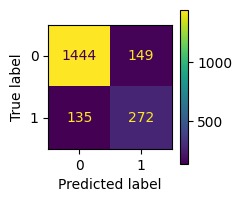

(0.6992356264539714, 0.6570048309178744)

In [1680]:
tuned_svm = SVC(C=10, class_weight={0: 0.35, 1: 0.65}, gamma=0.1, random_state=RANDOM_STATE)
test_model(tuned_svm, x_scaled, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING)

## Multilayer Perceptron

MLPClassifier(random_state=123)
selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.78      6370
           1       0.25      0.31      0.27      1630

    accuracy                           0.67      8000
   macro avg       0.53      0.53      0.53      8000
weighted avg       0.70      0.67      0.68      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78      1593
           1       0.24      0.31      0.27       407

    accuracy                           0.66      2000
   macro avg       0.53      0.53      0.53      2000
weighted avg       0.69      0.66      0.68      2000



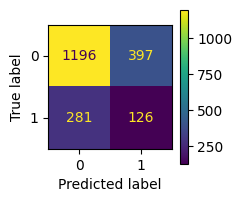

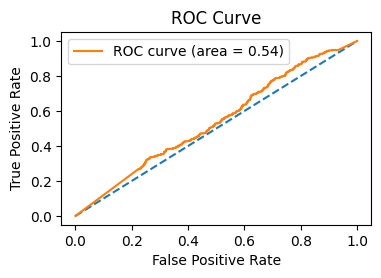

(0.2739427012278308, 0.2709677419354839)

In [1681]:
mlp = MLPClassifier(random_state=RANDOM_STATE)
test_model(mlp, x, y)

## Tuned Multilayer Perceptron

MLPClassifier(max_iter=600, random_state=123)
selected_outliers=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      6370
           1       0.79      0.59      0.67      1582

    accuracy                           0.89      7952
   macro avg       0.85      0.77      0.80      7952
weighted avg       0.88      0.89      0.88      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1593
           1       0.70      0.60      0.65       407

    accuracy                           0.87      2000
   macro avg       0.80      0.77      0.78      2000
weighted avg       0.86      0.87      0.86      2000



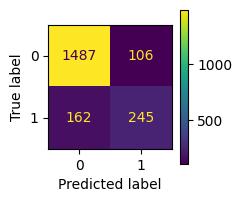

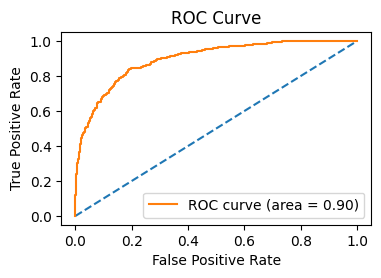

MLPClassifier(max_iter=600, random_state=123)
selected_outliers=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88      6370
           1       0.87      0.90      0.88      6370

    accuracy                           0.88     12740
   macro avg       0.88      0.88      0.88     12740
weighted avg       0.88      0.88      0.88     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       0.96      0.80      0.87      1593
           1       0.53      0.87      0.66       407

    accuracy                           0.82      2000
   macro avg       0.74      0.84      0.77      2000
weighted avg       0.87      0.82      0.83      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


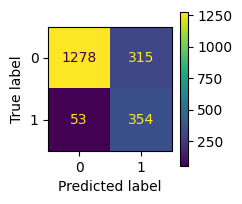

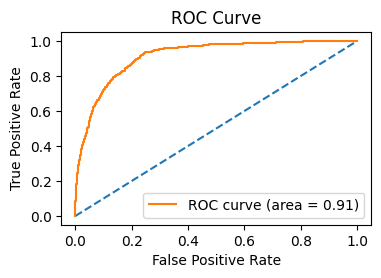

(0.8815363257751041, 0.6579925650557621)

In [1682]:
mlp = MLPClassifier(random_state=RANDOM_STATE, max_iter=200*3)
test_model(mlp, x_scaled, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING)
test_model(mlp, x_scaled, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, upsample_minority=True)

## Logistic Regression

LogisticRegression(random_state=123)
selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      6370
           1       0.43      0.07      0.12      1630

    accuracy                           0.79      8000
   macro avg       0.62      0.52      0.50      8000
weighted avg       0.73      0.79      0.73      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1593
           1       0.42      0.07      0.13       407

    accuracy                           0.79      2000
   macro avg       0.61      0.52      0.50      2000
weighted avg       0.73      0.79      0.73      2000



C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


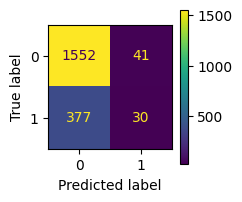

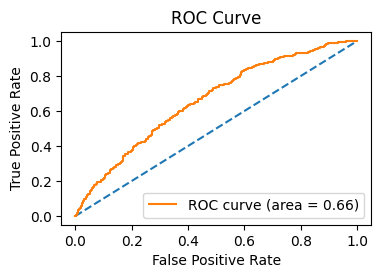

(0.12480335605663345, 0.12552301255230125)

In [1708]:
lr = LogisticRegression(random_state=RANDOM_STATE)
test_model(lr, x, y)

## Tune Logistic Regression (Regularization)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   solver='liblinear')
selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      6370
           1       0.39      0.70      0.50      1630

    accuracy                           0.72      8000
   macro avg       0.65      0.71      0.65      8000
weighted avg       0.80      0.72      0.74      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.89      0.70      0.79      1593
           1       0.37      0.67      0.47       407

    accuracy                           0.70      2000
   macro avg       0.63      0.69      0.63      2000
weighted avg       0.79      0.70      0.72      2000



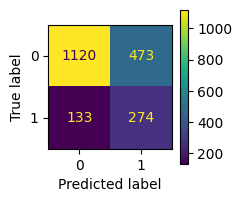

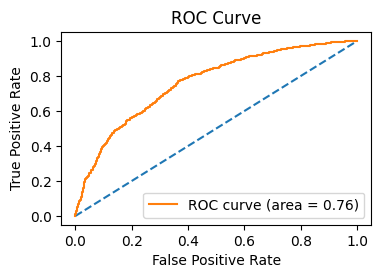

(0.5017559262510974, 0.4748700173310225)

In [1733]:
tuned_lr = LogisticRegression(penalty="l2", solver="liblinear", C=0.1, class_weight="balanced", max_iter=1000)
test_model(tuned_lr, x_scaled, y)

## Run Tuned Logistic Regression

LogisticRegression(class_weight={0: 0.25, 1: 0.75}, random_state=123)
selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      6370
           1       0.44      0.60      0.51      1630

    accuracy                           0.76      8000
   macro avg       0.66      0.70      0.67      8000
weighted avg       0.80      0.76      0.77      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1593
           1       0.40      0.58      0.48       407

    accuracy                           0.74      2000
   macro avg       0.64      0.68      0.65      2000
weighted avg       0.78      0.74      0.76      2000



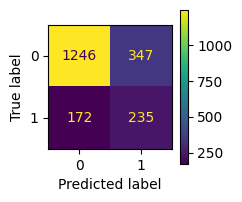

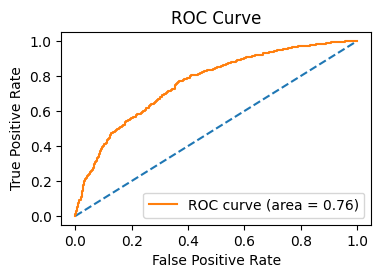

(0.5063225806451613, 0.4752275025278059)

In [1734]:
tuned_lr = LogisticRegression(random_state=RANDOM_STATE, class_weight={0: 0.25, 1: 0.75})
test_model(tuned_lr, x_scaled, y)

## Gaussian Naive Bayes

GaussianNB()
selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.88      6370
           1       0.38      0.08      0.14      1630

    accuracy                           0.79      8000
   macro avg       0.59      0.52      0.51      8000
weighted avg       0.72      0.79      0.73      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1593
           1       0.33      0.09      0.14       407

    accuracy                           0.78      2000
   macro avg       0.57      0.52      0.50      2000
weighted avg       0.71      0.78      0.72      2000



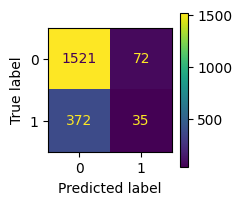

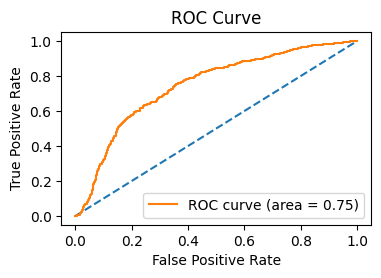

(0.13855421686746988, 0.13618677042801555)

In [1703]:
nb = GaussianNB()
test_model(nb, x, y)

## Run Tuned Gaussian Naive Bayes

GaussianNB()
selected_outliers=[], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       0.69      0.74      0.72      6370
           1       0.72      0.67      0.70      6370

    accuracy                           0.71     12740
   macro avg       0.71      0.71      0.71     12740
weighted avg       0.71      0.71      0.71     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1593
           1       0.40      0.70      0.51       407

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.66      2000
weighted avg       0.80      0.72      0.75      2000



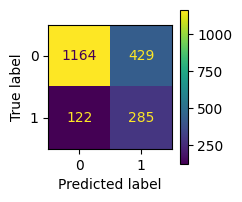

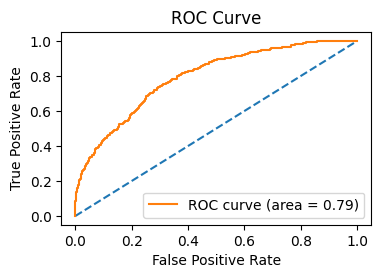

(0.6979352950739717, 0.5084745762711864)

In [1686]:
nb = GaussianNB()
test_model(nb, x_scaled, y, upsample_minority=True)

## Random Forest

RandomForestClassifier(random_state=123)
selected_outliers=[], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      1630

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000


Test Report and Results:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.51      0.62       407

    accuracy                           0.87      2000
   macro avg       0.84      0.74      0.77      2000
weighted avg       0.87      0.87      0.86      2000



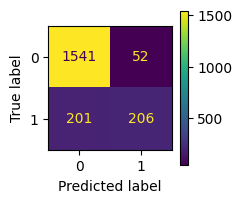

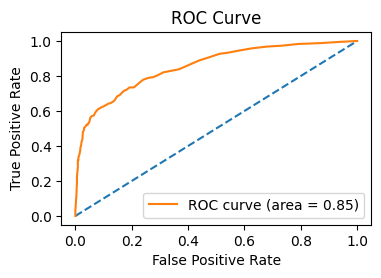

(1.0, 0.6195488721804512)

In [1687]:
forest = RandomForestClassifier(random_state=RANDOM_STATE)
test_model(forest, x, y)

## Run Tuned Random Forest

RandomForestClassifier(random_state=123)
selected_outliers=['NumOfProducts'], upsample_minority=True, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      6370

    accuracy                           1.00     12740
   macro avg       1.00      1.00      1.00     12740
weighted avg       1.00      1.00      1.00     12740


Test Report and Results:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1593
           1       0.75      0.99      0.85       407

    accuracy                           0.93      2000
   macro avg       0.87      0.95      0.90      2000
weighted avg       0.95      0.93      0.93      2000



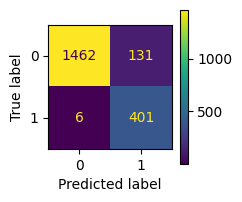

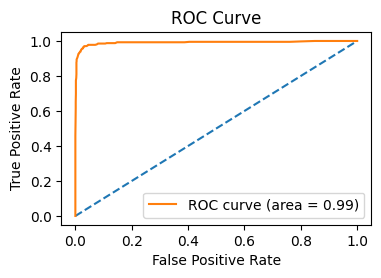

RandomForestClassifier(class_weight={0: 0.35, 1: 0.65}, random_state=123)
selected_outliers=['NumOfProducts'], upsample_minority=False, add_synthetic_training_data=False

Training Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      1582

    accuracy                           1.00      7952
   macro avg       1.00      1.00      1.00      7952
weighted avg       1.00      1.00      1.00      7952


Test Report and Results:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1593
           1       0.87      0.89      0.88       407

    accuracy                           0.95      2000
   macro avg       0.92      0.93      0.92      2000
weighted avg       0.95      0.95      0.95      2000



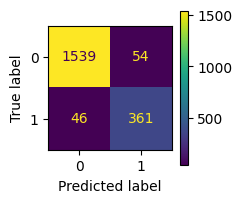

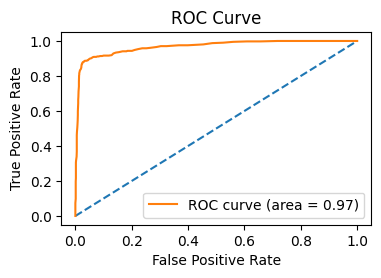

(1.0, 0.878345498783455)

In [1688]:
forest = RandomForestClassifier(random_state=RANDOM_STATE)
test_model(forest, x, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, upsample_minority=True)

forest = RandomForestClassifier(random_state=RANDOM_STATE, class_weight={0: 0.35, 1: 0.65})
test_model(forest, x, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING)